## Balance de carga y minimización de comunicación
### MA2015 - Diseño de Algoritmos Bioinspirados

Viviana Carrizales Luna (A01286191) & Steffany Mishell Lara Muy (A00838589)
*Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)*

Tienes 30 microservicios que deben distribuirse entre 2 clusters en la nube. Cada servicio tiene un consumo de CPU y existe comunicación entre ellos. Distribuir las 30 tareas entre 2 clusters optimizando:

Balance de carga (diferencia ≤ 10% entre clusters)

Minimización de comunicación entre clusters

In [1]:
import pandas as pd
data = pd.read_excel('data\sistema_balance_carga_30_tareas.xlsx')

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Vivi\AppData\Local\Temp\ipykernel_26124\2827658394.py:2: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_excel('data\sistema_balance_carga_30_tareas.xlsx')


In [2]:
# Cargas
C = data['Unnamed: 1'][3:33].reset_index(drop=True).tolist()


In [3]:
# Matriz de comunicación entre tareas
import pandas as pd

df = data[["Unnamed: 3", "Unnamed: 4", "Unnamed: 5"] ][2:]
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

tareas = [f"T{i:02d}" for i in range(1, 31)]

matriz = pd.DataFrame(0, index=tareas, columns=tareas)

for _, row in df.iterrows():
    origen = row["Tarea Origen"]
    destino = row["Tarea Destino"]
    volumen = row["Volumen (MB/s)"]
    matriz.loc[origen, destino] = volumen

matriz


,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,...,T21,T22,T23,T24,T25,T26,T27,T28,T29,T30
T01,0,74,94,0,96,0,27,0,57,0,...,0,73,0,0,0,84,0,69,0,0
T02,0,0,28,0,0,83,95,0,0,0,...,0,47,0,0,0,0,0,0,0,0
T03,0,0,0,23,0,0,0,0,0,0,...,38,0,0,0,0,0,36,18,0,0
T04,80,50,0,0,67,0,22,0,99,30,...,0,0,0,0,81,0,0,0,0,64
T05,0,0,0,0,0,16,20,0,0,0,...,31,0,0,41,0,77,0,26,0,0
T06,37,0,0,0,0,0,74,0,0,21,...,0,77,37,0,0,85,0,0,0,23
T07,0,0,0,0,0,0,0,85,0,23,...,0,0,0,0,0,0,0,0,0,56
T08,0,31,56,68,0,0,0,0,58,0,...,0,81,0,0,0,51,0,57,91,56
T09,0,0,11,0,40,0,86,0,0,22,...,0,0,15,35,0,39,0,0,0,42
T10,27,18,0,0,76,0,0,0,0,0,...,46,0,14,96,0,63,0,0,0,35


### Modelo exacto

In [ ]:
import pulp
import pandas as pd
import numpy as np

prob = pulp.LpProblem("BalanceCarga", pulp.LpMinimize)

# Variables x_i ∈ {0,1}
x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(30)]

# Variables y_ij ∈ {0,1}
y = [[pulp.LpVariable(f"y_{i}_{j}", cat="Binary") for j in range(30)] for i in range(30)]

# y_ij = |x_i - x_j|
for i in range(30):
    for j in range(30):
        prob += y[i][j] >= x[i] - x[j]
        prob += y[i][j] >= x[j] - x[i]

# Objetivo
prob += pulp.lpSum(
    matriz.iloc[i, j] * y[i][j]
    for i in range(30)
    for j in range(i+1, 30)
)


# Carga total y límites del 10%
T = sum(C)
lower = 0.45 * T
upper = 0.55 * T

# Carga de cada cluster
cargaB = pulp.lpSum(C[i] * x[i] for i in range(30))
cargaA = T - cargaB

# Restricción de balance del 10% (CORRECTA)
prob += cargaA >= lower
prob += cargaA <= upper

prob += cargaB >= lower
prob += cargaB <= upper

prob.solve()

clusterA = [i for i in range(30) if pulp.value(x[i]) == 0]
clusterB = [i for i in range(30) if pulp.value(x[i]) == 1]

print("Cluster A:", clusterA)
print("Cluster B:", clusterB)
print("\nCargas:")
print("Carga A =", sum(C[i] for i in clusterA))
print("Carga B =", sum(C[i] for i in clusterB))
print("\nObjetivo:", pulp.value(prob.objective))
print("Status:", pulp.LpStatus[prob.status])


Cluster A: [0, 1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 20, 21, 23, 25, 29]
Cluster B: [2, 10, 13, 14, 15, 16, 17, 18, 19, 22, 24, 26, 27, 28]

Cargas:
Carga A = 248
Carga B = 232

Objetivo: 2120.0
Status: Optimal


In [5]:
# Carga total por cluster
carga_A = sum(C[i] * (1 - pulp.value(x[i])) for i in range(30))
carga_B = sum(C[i] * pulp.value(x[i]) for i in range(30))

diferencia_abs = abs(carga_A - carga_B)
diferencia_pct = diferencia_abs / (carga_A + carga_B)

# Comunicación cruzada
com_cross = 0
for i in clusterA:
    for j in clusterB:
        com_cross += matriz.iloc[i, j]


print(f"Carga Cluster A: {carga_A}")
print(f"Carga Cluster B: {carga_B}")

print(f"\nDiferencia absoluta: {diferencia_abs}")
print(f"Diferencia porcentual: {diferencia_pct:.4f}")

print(f"\nComunicación cruzada: {com_cross}")
print(f"Valor objetivo: {pulp.value(prob.objective)}")


Carga Cluster A: 248.0
Carga Cluster B: 232.0

Diferencia absoluta: 16.0
Diferencia porcentual: 0.0333

Comunicación cruzada: 2714
Valor objetivo: 2120.0


### Algoritmo genético

In [1]:
## Funciones
import random
import numpy

M = matriz.to_numpy()
C = np.array(C)
# Implements the random initialization of individuals using the binary representation.
def createIndividual(nbBits):
  return numpy.random.randint(2, size = nbBits)

# Implements the one point crossover on individuals using the binary representation.
def combine(parentA, parentB, cRate):
  if (random.random() <= cRate):
    cPoint = numpy.random.randint(1, len(parentA))   
    offspringA = numpy.append(parentA[0:cPoint], parentB[cPoint:])
    offspringB = numpy.append(parentB[0:cPoint], parentA[cPoint:])
  else:
    offspringA = numpy.copy(parentA)
    offspringB = numpy.copy(parentB)
  return offspringA, offspringB

# Implements the flip mutation on individuals using the binary representation.
def mutate(individual, mRate):
  for i in range(len(individual)):
    if (random.random() <= mRate):
      if (individual[i] == 0):
        individual[i] = 1        
      else:
        individual[i] = 0        
  return individual



def evaluate(individual, M, C, alpha=10000):
    n = len(individual)
    
    cross = 0
    for i in range(n):
        for j in range(i+1, n):
            if individual[i] != individual[j]:
                cross += M[i, j]

    # Cargas
    cargaA = sum(C[i] for i in range(n) if individual[i] == 0)
    cargaB = sum(C[i] for i in range(n) if individual[i] == 1)
    T = cargaA + cargaB
    target = T / 2
    tol = 0.05 * T

    exceso = abs(cargaA - target) - tol
    penalty = alpha * max(0, exceso)

    return cross + penalty


# Implements the tournament selection.
def select(population, evaluation, tournamentSize):
  winner = numpy.random.randint(0, len(population))
  for i in range(tournamentSize - 1):
    rival = numpy.random.randint(0, len(population))
    if (evaluation[rival] < evaluation[winner]):
      winner = rival
  return population[winner]

# Implements a genetic algorithm for solving the max-one problem with individuals using the binary representation.
def geneticAlgorithm(n, populationSize, cRate, mRate, generations):
  # Creates the initial population (it also evaluates it)
  population = [None] * populationSize
  evaluation = [None] * populationSize  
  for i in range(populationSize):
    individual = createIndividual(n)
    population[i] = individual
    evaluation[i] = evaluate(individual, M, C)
  # Keeps a record of the best individual found so far
  index = 0;
  for i in range(1, populationSize):
    if (evaluation[i] < evaluation[index]):
      index = i;
  bestIndividual = population[index]
  bestEvaluation = evaluation[index]
  # Runs the evolutionary process    
  for i in range(generations):
    k = 0
    newPopulation = [None] * populationSize    
    for j in range(populationSize // 2):
      parentA = select(population, evaluation, 3)
      parentB = select(population, evaluation, 3)
      newPopulation[k], newPopulation[k + 1] = combine(parentA, parentB, cRate)       
      k = k + 2    
    population = newPopulation
    for j in range(populationSize):
      population[j] = mutate(population[j], mRate)
      evaluation[j] = evaluate(population[j], M, C)
      # Keeps a record of the best individual found so far
      if (evaluation[j] < bestEvaluation):
        bestEvaluation = evaluation[j]
        bestIndividual = population[j]
  return bestIndividual, bestEvaluation



NameError: name 'matriz' is not defined

In [7]:

solution, evaluation = geneticAlgorithm(30, 20, 0.9, 0.01, 100)
print("Best solution:", solution)
print("Best evaluation:", evaluation)

carga_A = sum(C[i] for i in range(30) if solution[i] == 0)
carga_B = sum(C[i] for i in range(30) if solution[i] == 1)
diferencia_abs = abs(carga_A - carga_B)
diferencia_pct = diferencia_abs / (carga_A + carga_B)   
# Comunicación cruzada
com_cross = 0
clusterA = [i for i in range(30) if solution[i] == 0]
clusterB = [i for i in range(30) if solution[i] == 1]
for i in clusterA:
    for j in clusterB:
        com_cross += matriz.iloc[i, j]
print("Cluster A:", clusterA)
print("Cluster B:", clusterB)   
print("\nCargas:")
print("Carga A =", carga_A)
print("Carga B =", carga_B)
print("\Com cross:", com_cross)
print("\nDiferencia absoluta:", diferencia_abs) 
print("Diferencia porcentual:", diferencia_pct)


<>:21: SyntaxWarning: invalid escape sequence '\C'
<>:21: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Vivi\AppData\Local\Temp\ipykernel_26124\3206785563.py:21: SyntaxWarning: invalid escape sequence '\C'
  print("\Com cross:", com_cross)


Best solution: [0 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1 1]
Best evaluation: 2323
Cluster A: [0, 1, 2, 4, 13, 14, 16, 17, 18, 19, 20, 25, 26, 27]
Cluster B: [3, 5, 6, 7, 8, 9, 10, 11, 12, 15, 21, 22, 23, 24, 28, 29]

Cargas:
Carga A = 234
Carga B = 246
\Com cross: 3182

Diferencia absoluta: 12
Diferencia porcentual: 0.025


## Scheduling 

Una universidad tiene n cursos y sabemos qué pares de cursos comparten estudiantes. Queremos asignar horarios de modo que ningún estudiante tenga dos exámenes a la misma hora.



In [1]:
import pandas as pd
grafo_20 = pd.read_excel('data\grafos_de_conflictos-1.xlsx',sheet_name='Grafo_20')
grafo_30 = pd.read_excel('data\grafos_de_conflictos-1.xlsx',sheet_name='Grafo_30')
grafo_50 = pd.read_excel('data\grafos_de_conflictos-1.xlsx',sheet_name='Grafo_50')
grafo_75 = pd.read_excel('data\grafos_de_conflictos-1.xlsx',sheet_name='Grafo_75')
garfo_100 = pd.read_excel('data\grafos_de_conflictos-1.xlsx',sheet_name='Grafo_100')
grafo_75

<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Vivi\AppData\Local\Temp\ipykernel_20992\1067363774.py:2: SyntaxWarning: invalid escape sequence '\g'
  grafo_20 = pd.read_excel('data\grafos_de_conflictos-1.xlsx',sheet_name='Grafo_20')
C:\Users\Vivi\AppData\Local\Temp\ipykernel_20992\1067363774.py:3: SyntaxWarning: invalid escape sequence '\g'
  grafo_30 = pd.read_excel('data\grafos_de_conflictos-1.xlsx',sheet_name='Grafo_30')
C:\Users\Vivi\AppData\Local\Temp\ipykernel_20992\1067363774.py:4: SyntaxWarning: invalid escape sequence '\g'


,Clase,Conflicto_1,Conflicto_2,Conflicto_3,Conflicto_4,Conflicto_5,Conflicto_6,Conflicto_7,Conflicto_8,Conflicto_9,Conflicto_10,Conflicto_11,Conflicto_12,Conflicto_13,Conflicto_14,Conflicto_15,Conflicto_16,Conflicto_17,Conflicto_18,Conflicto_19
0,C1,C6,C54,C34,C5,C10,C44,C42,C52,C38,C47,C71,C43,C49,C14,C11,C48,NaN,NaN,NaN
1,C2,C35,C54,C66,C7,C32,C36,C24,C41,C68,C59,C27,C30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C3,C26,C60,C46,C63,C66,C42,C57,C38,C22,C50,C72,C56,C14,C30,C36,C11,C27,NaN,NaN
3,C4,C23,C34,C39,C47,C45,C9,C68,C46,C11,C72,C13,C48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C5,C18,C35,C64,C52,C17,C7,C57,C12,C33,C74,C58,C49,C41,C1,C69,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,C71,C67,C60,C57,C17,C43,C74,C56,C68,C46,C1,C19,C13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,C72,C67,C10,C3,C63,C28,C51,C45,C56,C20,C41,C36,C8,C4,NaN,NaN,NaN,NaN,NaN,NaN
72,C73,C31,C63,C13,C50,C36,C65,C27,C62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,C74,C51,C44,C55,C8,C42,C52,C57,C37,C5,C29,C71,C9,C21,C11,C67,C31,C7,C43,C61


### Obtener grafo

In [5]:
import pulp
import numpy as np

import pandas as pd
import numpy as np

def df_to_edge_list(df):
    """
    Devuelve lista de aristas para GA, con nodos 1-indexados (enteros)
    """
    clases = df["Clase"].astype(str).tolist()
    index_map = {clase:i for i,clase in enumerate(clases)}
    conflicto_cols = [c for c in df.columns if "Conflicto" in c]
    E = set()
    for _, row in df.iterrows():
        clase = str(row["Clase"]).strip()
        i = index_map[clase] + 1  # 1-indexed
        for col in conflicto_cols:
            c = row[col]
            if pd.notna(c):
                c = str(c).strip()
                if c in index_map:
                    j = index_map[c] + 1  # 1-indexed
                    E.add(tuple(sorted((i,j))))
    return list(E), index_map


def df_to_edge_list_ilp(df):
    """
    Devuelve lista de aristas para ILP, usando nombres de clases (strings)
    """
    clases = df["Clase"].astype(str).tolist()
    index_map = {clase:i for i,clase in enumerate(clases)}
    conflicto_cols = [c for c in df.columns if "Conflicto" in c]
    E = set()
    for _, row in df.iterrows():
        clase = str(row["Clase"]).strip()
        for col in conflicto_cols:
            c = row[col]
            if pd.notna(c):
                c = str(c).strip()
                if c in index_map:
                    E.add(tuple(sorted((clase, c))))
    return list(E), index_map

def df_to_conflict_matrix(df):
    # Extraer nombres de clases
    clases = df['Clase'].tolist()
    n = len(clases)

    # Crear un mapeo: "C1" -> 0, "C2" -> 1, ...
    index_map = {clase: i for i, clase in enumerate(clases)}

    # Matriz de conflictos
    M = np.zeros((n, n), dtype=int)

    # Para cada fila, añadir los conflictos
    conflicto_cols = [c for c in df.columns if "Conflicto" in c]

    for _, row in df.iterrows():
        clase = row['Clase']
        i = index_map[clase]

        # Para cada conflicto listado
        for col in conflicto_cols:
            c = row[col]
            if pd.notna(c):  # Evitar NaN
                c = str(c).strip()
                j = index_map[c]
                M[i, j] = 1
                M[j, i] = 1  # Es grafo no dirigido

    return M, index_map


### Algoritmo genético

In [6]:
def contar_conflictos(crom, E):
    conf = 0
    for (i, j) in E:
        if crom[i-1] == crom[j-1]:
            conf += 1
    return conf

def normalize(crom):
    mapping = {}
    next_color = 1
    norm = []
    for c in crom:
        if c not in mapping:
            mapping[c] = next_color
            next_color += 1
        norm.append(mapping[c])
    return norm

def select_parent(pop, fit, k=3):
    candidates = random.sample(range(len(pop)), k)
    candidates.sort(key=lambda i: fit[i])
    return pop[candidates[0]]

def crossover(p1, p2):
    n = len(p1)
    punto = random.randint(1, n-2)
    hijo = p1[:punto] + p2[punto:]
    return normalize(hijo)

def mutar(crom, k, E):
    n = len(crom)
    i = random.randint(0, n-1)
    original = crom[i]
    mejor_color = original
    mejor_conf = contar_conflictos(crom, E)
    for color in range(1, k+1):
        if color == original:
            continue
        crom[i] = color
        c = contar_conflictos(crom, E)
        if c < mejor_conf:
            mejor_conf = c
            mejor_color = color
    crom[i] = mejor_color
    return crom



def algoritmo_genetico(E, n, max_total_gens=200, gens_per_step=20, pop_size=80, mutation_rate=0.25):
    """
    Algoritmo Genético Iterativo para Coloración de Grafos.
    Utiliza un presupuesto global de generaciones (max_total_gens) para controlar el tiempo.
    """
    def crear_individuo(k):
        # Asume que k es el límite superior de colores disponibles
        return [random.randint(1, k) for _ in range(n)]
    
    k = 1 # Número inicial de colores a probar
    total_gens_run = 0 # Contador del presupuesto global
    
    mejores, proms, peores = [], [], []
    poblacion = None
    
    # 1. Bucle Externo: Búsqueda Secuencial de k con Presupuesto Global
    while k <= n and total_gens_run < max_total_gens:
        
        # Inicialización o Ajuste de la Población (al nuevo k)
        if poblacion is None:
            poblacion = [crear_individuo(k) for _ in range(pop_size)]
        else:
            # Ajuste de la población (probabilidad de reasignar al nuevo color k)
            for ind in poblacion:
                if random.random() < 0.3:
                    pos = random.randint(0, n-1)
                    ind[pos] = k # Asigna el nuevo color disponible

        # Determinar cuántas generaciones correr en este paso
        gens_a_correr = min(gens_per_step, max_total_gens - total_gens_run)
        
        # 2. Bucle Interno: Ejecución del AG (Hasta que se agote el paso)
        for gen in range(gens_a_correr):
            
            # Evaluación
            fitness = [contar_conflictos(ind, E) for ind in poblacion]
            
            # Registrar historial (continúa el historial global)
            mejores.append(min(fitness))
            proms.append(sum(fitness) / len(fitness))
            peores.append(max(fitness))
            
            # Condición de éxito: Cero conflictos
            if min(fitness) == 0:
                best_idx = np.argmin(fitness)
                return poblacion[best_idx], k, 0, mejores, proms, peores
            
            # Selección, Elitismo y Reproducción
            elite_idx = np.argmin(fitness)
            elite = poblacion[elite_idx][:]
            new_pop = [elite] 
            
            # Reproducción (Cruce y Mutación)
            while len(new_pop) < pop_size:
                p1 = select_parent(poblacion, fitness)
                p2 = select_parent(poblacion, fitness)
                hijo = crossover(p1, p2)
                
                if random.random() < mutation_rate:
                    hijo = mutar(hijo, k, E) 
                
                new_pop.append(hijo)
                
            poblacion = new_pop # Reemplazo Generacional
            
        # 3. Actualizar presupuesto total y pasar al siguiente color si es necesario
        total_gens_run += gens_a_correr
        
        # Si todavía queda presupuesto, avanzamos al siguiente color k+1
        if total_gens_run < max_total_gens:
            k += 1 

    # Condición de fallo (Presupuesto agotado o k > n)
    if poblacion is not None:
        # Re-evaluar (si el último bucle interno no fue completado)
        fitness = [contar_conflictos(ind, E) for ind in poblacion] 
        best_idx = np.argmin(fitness)
        
        # Retorna el mejor resultado parcial encontrado
        return poblacion[best_idx], k, min(fitness), mejores, proms, peores
    else:
        return None, 0, 0, [], [], []


In [7]:
import pandas as pd
import numpy as np
import os
import time
import random
import collections 

def get_schedule(solucion):
    """
    Convierte la solución (diccionario nodo:color) en una distribución hora:lista_de_nodos.
    """
    if not isinstance(solucion, dict):
        sol_dict = {i + 1: color for i, color in enumerate(solucion)}
    else:
        sol_dict = solucion

    schedule = collections.defaultdict(list)
    for nodo, color in sol_dict.items():
        schedule[color].append(nodo)
    
    return dict(sorted(schedule.items()))



def run_experiments_ga(path_excel, out_dir="results", repeats=5):

    os.makedirs(out_dir, exist_ok=True)

    xls = pd.ExcelFile(path_excel)
    sheets = xls.sheet_names

    summary_rows = []
    detailed_rows = []

    schedule_rows = [] 

    for sheet in sheets:

        if "Grafo" not in sheet and "grafo" not in sheet:
            continue

        print(f"\n--- Procesando grafo: {sheet} ---")

        df = pd.read_excel(path_excel, sheet_name=sheet)

        M, idx_map = df_to_conflict_matrix(df)
        E_ga, idx_map_ga = df_to_edge_list(df) 
        n = len(idx_map_ga)

        tiempos = []
        objetivos = []
        colores_usados = []
    
        last_schedule = None

        for r in range(repeats):

            print(f"  → corrida {r+1}...", end=" ")

            t0 = time.time()
            # La solución 'sol' es un vector de coloración, no un diccionario.
            sol, k, conf, hbest, hmean, hworst = algoritmo_genetico(E_ga, n) 
            t1 = time.time()

            tiempos.append(t1 - t0)
            objetivos.append(conf)
            colores_usados.append(k)

            schedule_map = get_schedule(sol)
            last_schedule = schedule_map 
            schedule_rows.append({
                "sheet": sheet,
                "run": r,
                "n": n,
                "num_colores": k,
                "horario": schedule_map
            })


            detailed_rows.append(pd.DataFrame({
                "sheet": sheet,
                "run": r,
                "gen": list(range(len(hbest))),
                "mejor": hbest,
                "prom": hmean,
                "peor": hworst
            }))

            print(f"colores={k}, conflictos={conf}, tiempo={t1-t0:.2f}s")

        # 2. Agregar el promedio y el horario de ejemplo
        summary_rows.append({
            "sheet": sheet,
            "n": n,
            "avg_tiempo": np.mean(tiempos),
            "avg_conflictos": np.mean(objetivos),
            "avg_colores": np.mean(colores_usados),
            "ejemplo_horario": last_schedule # Horario de la última corrida como ejemplo
        })

    # Consolidar resultados
    summary = pd.DataFrame(summary_rows)
    detailed = pd.concat(detailed_rows, ignore_index=True)
    schedules = pd.DataFrame(schedule_rows) # Nuevo DF de horarios

    summary.to_csv(f"{out_dir}/summary.csv", index=False)
    detailed.to_csv(f"{out_dir}/detailed.csv", index=False)
    schedules.to_csv(f"{out_dir}/schedules.csv", index=False) # Guardar horarios

    print("\n✔ Resultados guardados en:", out_dir)
    return summary, detailed, schedules




In [8]:
summary_ex, detailed_ex, schedules_ex = run_experiments_ga("data/grafos_de_conflictos-1.xlsx",
                                    out_dir="results_exam",
                                    repeats=5)



--- Procesando grafo: Grafo_20 ---
  → corrida 1... colores=8, conflictos=0, tiempo=0.64s
  → corrida 2... colores=9, conflictos=0, tiempo=0.50s
  → corrida 3... colores=8, conflictos=0, tiempo=0.60s
  → corrida 4... colores=9, conflictos=0, tiempo=0.80s
  → corrida 5... colores=8, conflictos=0, tiempo=0.43s

--- Procesando grafo: Grafo_30 ---
  → corrida 1... colores=8, conflictos=0, tiempo=0.59s
  → corrida 2... colores=7, conflictos=0, tiempo=0.44s
  → corrida 3... colores=6, conflictos=0, tiempo=0.62s
  → corrida 4... colores=7, conflictos=0, tiempo=0.61s
  → corrida 5... colores=7, conflictos=0, tiempo=0.52s

--- Procesando grafo: Grafo_50 ---
  → corrida 1... colores=8, conflictos=0, tiempo=1.51s
  → corrida 2... colores=7, conflictos=0, tiempo=0.63s
  → corrida 3... colores=7, conflictos=0, tiempo=1.08s
  → corrida 4... colores=7, conflictos=0, tiempo=0.84s
  → corrida 5... colores=8, conflictos=0, tiempo=0.88s

--- Procesando grafo: Grafo_75 ---
  → corrida 1... colores=8, con

In [2]:
schedules_ex = pd.read_csv("results_exam/schedules.csv")
schedules_ex

,sheet,run,n,num_colores,horario
0,Grafo_20,0,20,8,"{1: [1, 4, 8, 15], 2: [2, 14], 3: [3, 11, 12],..."
1,Grafo_20,1,20,9,"{1: [1, 4, 8, 15], 2: [2, 5], 3: [3, 11, 13], ..."
2,Grafo_20,2,20,8,"{1: [1, 4, 8, 15], 2: [2, 5], 3: [3, 11, 13], ..."
3,Grafo_20,3,20,9,"{1: [1, 4, 9], 2: [2, 8, 14], 3: [3, 17, 19], ..."
4,Grafo_20,4,20,8,"{1: [1, 15], 2: [2, 3, 13], 3: [4, 6, 18], 4: ..."
5,Grafo_30,0,30,8,"{1: [5, 9, 22, 24, 26, 29], 2: [2, 3, 7, 16, 1..."
6,Grafo_30,1,30,7,"{1: [1, 3, 6, 7, 9, 13, 19], 2: [2, 10, 22, 24..."
7,Grafo_30,2,30,6,"{1: [1, 6, 9, 22, 24, 28, 29], 2: [2, 5, 21, 2..."
8,Grafo_30,3,30,7,"{1: [1, 2, 3, 7, 22, 24], 2: [4, 8, 21], 3: [5..."
9,Grafo_30,4,30,7,"{1: [1, 7, 15, 22, 26], 2: [4, 11, 21], 3: [3,..."


In [4]:
summary_ex = pd.read_csv("results_exam/summary.csv")
summary_ex

,sheet,n,avg_tiempo,avg_conflictos,avg_colores,ejemplo_horario
0,Grafo_20,20,0.593469,0.0,8.4,"{1: [1, 15], 2: [2, 3, 13], 3: [4, 6, 18], 4: ..."
1,Grafo_30,30,0.557054,0.0,7.0,"{1: [1, 7, 15, 22, 26], 2: [4, 11, 21], 3: [3,..."
2,Grafo_50,50,0.987429,0.0,7.4,"{1: [1, 2, 17, 26, 30, 31, 36, 37, 49], 2: [3,..."
3,Grafo_75,75,1.301403,0.0,8.4,"{1: [1, 3, 12, 17, 23, 28, 33, 45, 68, 73, 74]..."
4,Grafo_100,100,2.363501,0.0,8.6,"{1: [1, 13, 19, 21, 23, 24, 25, 27, 28, 30, 33..."


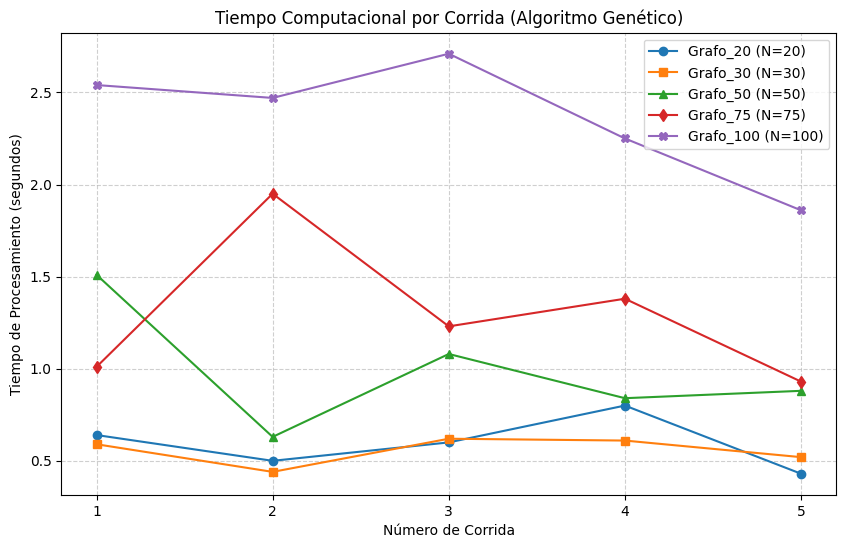

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos (en segundos)
corridas = np.arange(1, 6) # Eje X: 1, 2, 3, 4, 5

tiempos_g20 = [0.64, 0.50, 0.60, 0.80, 0.43]
tiempos_g30 = [0.59, 0.44, 0.62, 0.61, 0.52]
tiempos_g50 = [1.51, 0.63, 1.08, 0.84, 0.88]
tiempos_g75 = [1.01, 1.95, 1.23, 1.38, 0.93]
tiempos_g100 = [2.54, 2.47, 2.71, 2.25, 1.86]

plt.figure(figsize=(10, 6))

# Dibujar cada grafo con un color diferente
plt.plot(corridas, tiempos_g20, marker='o', label='Grafo_20 (N=20)')
plt.plot(corridas, tiempos_g30, marker='s', label='Grafo_30 (N=30)')
plt.plot(corridas, tiempos_g50, marker='^', label='Grafo_50 (N=50)')
plt.plot(corridas, tiempos_g75, marker='d', label='Grafo_75 (N=75)')
plt.plot(corridas, tiempos_g100, marker='X', label='Grafo_100 (N=100)')

# Formato del gráfico
plt.title('Tiempo Computacional por Corrida (Algoritmo Genético)')
plt.xlabel('Número de Corrida')
plt.ylabel('Tiempo de Procesamiento (segundos)')
plt.xticks(corridas) # Asegura que el eje X solo muestre 1, 2, 3, 4, 5
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show() # Muestra y guarda esta imagen para tu reporte

### Modelo xacto

In [46]:
import time

 
def metodo_matematico(idx_map, E, V):
    """
    Busca el MÍNIMO número de colores usando programación lineal entera
    Estrategia: probar desde 1 color hasta encontrar solución factible
    """
    
    print("MÉTODO MATEMÁTICO (PuLP)")
    NUM_NODOS = len(idx_map)
    MAX_COLORES = NUM_NODOS
    
    inicio = time.time()
    
    # Probar desde 1 color hasta encontrar solución
    for num_colores in range(1, MAX_COLORES + 1):
        print(f"Probando con {num_colores} colores...", end=" ")
        
        # Crear el problema
        prob = pulp.LpProblem("Coloracion_Grafos", pulp.LpMinimize)
        
        # Variables: x[i][c] = 1 si nodo i tiene color c
        colores = range(1, num_colores + 1)
        x = {}
        for i in V:
            for c in colores:
                x[i, c] = pulp.LpVariable(f"x_{i}_{c}", cat='Binary')
        
        # Función objetivo: constante (solo buscamos factibilidad)
        prob += 0
        
        # Restricción 1: cada nodo tiene exactamente un color
        for i in V:
            prob += pulp.lpSum(x[i, c] for c in colores) == 1
        
        # Restricción 2: nodos adyacentes no pueden tener el mismo color
        for (i, j) in E:
            for c in colores:
                prob += x[i, c] + x[j, c] <= 1
        
        # Resolver
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        
        if prob.status == pulp.LpStatusOptimal:
            print("Funcionaaaaa!!!!!!")
            
            fin = time.time()
            tiempo = fin - inicio
            
            # Extraer solución
            solucion = {}
            for i in V:
                for c in colores:
                    if pulp.value(x[i, c]) == 1:
                        solucion[i] = c
            
            print(f"\n*** NÚMERO COLORES ENCONTRADO: {num_colores} ***")
            print(f"Tiempo total: {tiempo:.4f} segundos")
            print(f"Asignación: {solucion}")
            
            return solucion, num_colores, tiempo
        else:
            print("No factible")
    
    return None, MAX_COLORES, time.time() - inicio



In [48]:
import time
import pulp
import numpy as np
import pandas as pd

def metodo_matematico_binario(idx_map, E, V, k_max_ga=None):
    NUM_NODOS = len(idx_map)
    k_max = NUM_NODOS if k_max_ga is None else min(k_max_ga, NUM_NODOS)
    k_min = 1
    solucion_final = None
    inicio = time.time()
    
    while k_min <= k_max:
        k = (k_min + k_max)//2
        prob = pulp.LpProblem("Coloracion_Grafos", pulp.LpMinimize)
        colores = range(1, k+1)
        x = {}
        for i in V:
            for c in colores:
                x[i,c] = pulp.LpVariable(f"x_{i}_{c}", cat='Binary')
        prob += 0
        for i in V:
            prob += pulp.lpSum(x[i,c] for c in colores) == 1
        for (i,j) in E:
            for c in colores:
                prob += x[i,c] + x[j,c] <= 1
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        if prob.status == pulp.LpStatusOptimal:
            solucion_final = {}
            for i in V:
                for c in colores:
                    if pulp.value(x[i,c]) == 1:
                        solucion_final[i] = c
            k_max = k - 1
        else:
            k_min = k + 1
    fin = time.time()
    tiempo_total = fin - inicio
    if solucion_final is not None:
        num_colores = max(solucion_final.values())
        return solucion_final, num_colores, tiempo_total
    else:
        return None, None, tiempo_total


In [17]:
import os
def run_experiments_ga_ilp(path_excel, out_dir="results", repeats=5, generaciones_ga=20):
    
    os.makedirs(out_dir, exist_ok=True)
    xls = pd.ExcelFile(path_excel)
    sheets = xls.sheet_names
    
    summary_rows = []
    detailed_rows = []

    for sheet in sheets:
        if "Grafo" not in sheet and "grafo" not in sheet:
            continue
        
        print(f"\n--- Procesando grafo: {sheet} ---")
        df = pd.read_excel(path_excel, sheet_name=sheet)

        E_ga, idx_map_ga = df_to_edge_list(df)
        n = len(idx_map_ga)
        E_ilp, idx_map_ilp = df_to_edge_list_ilp(df)
        V_ilp = list(idx_map_ilp.keys())

        tiempos_ga, tiempos_ilp = [], []
        colores_ga, colores_ilp = [], []
        conflictos_ga = []
        
        # Variables para almacenar el horario de la última corrida como ejemplo
        last_schedule_ga = None 
        last_schedule_ilp = None 

        for r in range(repeats):
            
            # --- 1. Ejecución del AG (Heurística) ---
            print(f"\nCorrida {r+1} del GA...")
            t0 = time.time()
            sol_ga, k_ga, conf_ga, hbest, hmean, hworst = algoritmo_genetico(E_ga, n)
            t1 = time.time()
            tiempos_ga.append(t1-t0)
            colores_ga.append(k_ga)
            conflictos_ga.append(conf_ga)

            # Capturar y guardar horario del AG
            last_schedule_ga = get_schedule(sol_ga) 

            detailed_rows.append(pd.DataFrame({
                # ... (resto de columnas)
                "sheet": sheet, "run": r, "metodo": "GA",
                "gen": list(range(len(hbest))), "mejor": hbest, "prom": hmean, "peor": hworst
            }))
            print(f"  GA: colores={k_ga}, conflictos={conf_ga}, tiempo={t1-t0:.2f}s")
            
            # --- 2. Ejecución del ILP (Exacto) ---
            t2 = time.time() 
            sol_ilp, k_ilp, tiempo_ilp = metodo_matematico_binario(idx_map_ilp, E_ilp, V_ilp, k_max_ga=k_ga)
            t3 = time.time() 
            
            if tiempo_ilp is None:
                tiempo_ilp = t3 - t2
            
            tiempos_ilp.append(tiempo_ilp)
            colores_ilp.append(k_ilp)

            # Capturar y guardar horario del ILP
            last_schedule_ilp = get_schedule(sol_ilp) 

            # Registro detallado del ILP
            detailed_rows.append(pd.DataFrame({
                "sheet": sheet, "run": r, "metodo": "ILP",
                "gen": [0], "mejor": [k_ilp if k_ilp is not None else np.nan], 
                "prom": [np.nan], "peor": [np.nan]
            }))
            
            print(f"  ILP: colores={k_ilp}, tiempo={tiempo_ilp:.2f}s")

        # --- 3. Registro del Resumen Promediado con Horarios ---
        summary_rows.append({
            "sheet": sheet,
            "n": n,
            "avg_colores_ga": np.mean(colores_ga),
            "avg_conflictos_ga": np.mean(conflictos_ga),
            "avg_tiempo_ga": np.mean(tiempos_ga),
            "ejemplo_horario_ga": last_schedule_ga, # <-- NUEVO: Horario AG
            "avg_colores_ilp": np.mean(colores_ilp),
            "avg_tiempo_ilp": np.mean(tiempos_ilp),
            "ejemplo_horario_ilp": last_schedule_ilp # <-- NUEVO: Horario ILP
        })

    # Consolidar y guardar resultados
    summary = pd.DataFrame(summary_rows)
    detailed = pd.concat(detailed_rows, ignore_index=True)
    summary.to_csv(f"{out_dir}/summary.csv", index=False)
    detailed.to_csv(f"{out_dir}/detailed.csv", index=False)

    print("\n Experimentos completos. Resultados guardados en:", out_dir)
    return summary, detailed

In [18]:
summary, detailed,  = run_experiments_ga_ilp("data/grafos_de_conflictos-1.xlsx",
                                                          out_dir="results_exact_exam",
                                                          repeats=5)


--- Procesando grafo: Grafo_20 ---

Corrida 1 del GA...
  GA: colores=8, conflictos=0, tiempo=0.60s
  ILP: colores=8, tiempo=4.17s

Corrida 2 del GA...
  GA: colores=8, conflictos=0, tiempo=0.29s
  ILP: colores=8, tiempo=3.73s

Corrida 3 del GA...
  GA: colores=8, conflictos=0, tiempo=0.26s
  ILP: colores=8, tiempo=3.83s

Corrida 4 del GA...
  GA: colores=8, conflictos=0, tiempo=0.27s
  ILP: colores=8, tiempo=3.94s

Corrida 5 del GA...
  GA: colores=9, conflictos=0, tiempo=0.52s
  ILP: colores=8, tiempo=6.29s

--- Procesando grafo: Grafo_30 ---

Corrida 1 del GA...
  GA: colores=7, conflictos=0, tiempo=0.69s
  ILP: colores=6, tiempo=6.47s

Corrida 2 del GA...
  GA: colores=7, conflictos=0, tiempo=0.61s
  ILP: colores=6, tiempo=6.36s

Corrida 3 del GA...
  GA: colores=7, conflictos=0, tiempo=0.39s
  ILP: colores=6, tiempo=5.81s

Corrida 4 del GA...
  GA: colores=7, conflictos=0, tiempo=0.43s
  ILP: colores=6, tiempo=5.77s

Corrida 5 del GA...
  GA: colores=7, conflictos=0, tiempo=0.43s

: 

: 

In [ ]:
summary_exact, detailed_exact = run_experiments_exact(
    "data/grafos_de_conflictos-1.xlsx",
    out_dir="results_exact_lp",
    repeats=3
)



=== Procesando Grafo_20 ===

  -- Run 1 --
MÉTODO MATEMÁTICO (PuLP)
Probando con 1 colores... No factible
Probando con 2 colores... No factible
Probando con 3 colores... No factible
Probando con 4 colores... No factible
Probando con 5 colores... No factible
Probando con 6 colores... No factible
Probando con 7 colores... No factible
Probando con 8 colores... Funcionaaaaa!!!!!!

*** NÚMERO COLORES ENCONTRADO: 8 ***
Tiempo total: 3.2274 segundos
Asignación: {1: 2, 2: 1, 3: 1, 4: 3, 5: 5, 6: 3, 7: 6, 8: 4, 9: 5, 10: 6, 11: 8, 12: 8, 13: 1, 14: 4, 15: 2, 16: 7, 17: 5, 18: 3, 19: 7, 20: 4}

  -- Run 2 --
MÉTODO MATEMÁTICO (PuLP)
Probando con 1 colores... No factible
Probando con 2 colores... No factible
Probando con 3 colores... No factible
Probando con 4 colores... No factible
Probando con 5 colores... No factible
Probando con 6 colores... No factible
Probando con 7 colores... No factible
Probando con 8 colores... Funcionaaaaa!!!!!!

*** NÚMERO COLORES ENCONTRADO: 8 ***
Tiempo total: 3.214

## Marketing Dirigido

1. El marketing dirigido (también conocido como marketing objetivo o target marketing en inglés) es una estrategia que consiste en enfocar los esfuerzos y recursos de marketing en un segmento específico y bien definido del mercado total.

Una empresa de e-commerce quiere lanzar varias campañas de marketing digital, pero:

- Algunos clientes comparten características en común.

- No se deben asignar campañas iguales a clientes muy relacionados, porque puede generar saturación, canibalización o mensajes repetitivos.

Determina las campañas de marketing dirigidas, minimizando conflictos de mercado.

- ¿Qué categorías son más frecuentes en los 50 clientes?

2. Construcción del grafo de clientes

- Decidimos que dos clientes están en conflicto (es decir, no deben recibir la misma campaña) si comparten al menos 2 categorías de preferencia.
- El grafo obtenido refleja las comunidades de consumidores.
3. Solución.
¿Cuántas campañas fueron necesarias para cubrir a los 50 clientes sin conflictos?

In [ ]:
df_marketing = pd.read_excel('data\marketing_50_clientes.xlsx')
df_marketing

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Vivi\AppData\Local\Temp\ipykernel_20992\2101014782.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_marketing = pd.read_excel('data\marketing_50_clientes.xlsx')


,Cliente,Preferencias,Conflictos con,Campaña
0,C1,"Music, Gaming, Electronics","C4, C7, C27, C36",NaN
1,C2,"Streaming, Gourmet Food, Travel","C3, C16, C26, C28, C34, C40, C50",NaN
2,C3,"Travel, Books, Streaming","C2, C16, C26, C37, C38, C40, C50",NaN
3,C4,"Gaming, Music, Streaming","C1, C10, C27, C34, C36",NaN
4,C5,"Automotive, Home Decor, Gaming","C18, C22, C23",NaN
5,C6,"Beauty, Fitness, Electronics",NaN,NaN
6,C7,"Electronics, Gaming, Travel","C1, C9, C27, C29, C42, C45",NaN
7,C8,"Travel, Home Decor, Beauty","C9, C11, C26, C40, C45, C50",NaN
8,C9,"Electronics, Home Decor, Travel","C7, C8, C11, C40, C42, C50",NaN
9,C10,"Streaming, Music, Automotive","C4, C34, C35, C46",NaN


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Vivi\AppData\Local\Temp\ipykernel_20992\2108086473.py:7: SyntaxWarning: invalid escape sequence '\m'
  NOMBRE_ARCHIVO = 'data\marketing_50_clientes.xlsx'


## 1. Cargando y Preprocesando Datos desde 'data\marketing_50_clientes.xlsx'...
Datos de 50 clientes cargados.
--------------------------------------------------
## 2. Calculando Conflictos y Construyendo el Grafo (Umbral: 2 preferencias)
Grafo de Conflictos construido: 50 nodos, 94 aristas.
--------------------------------------------------


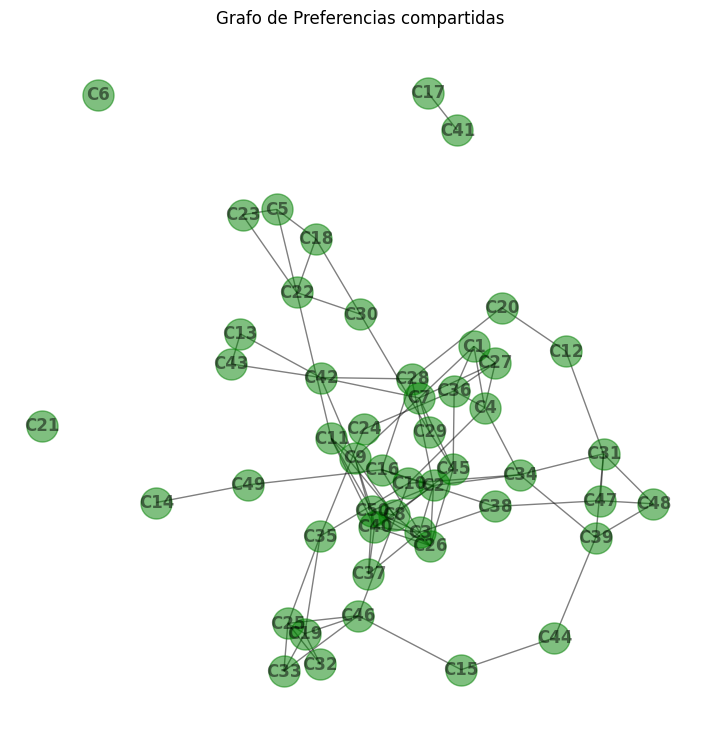

In [42]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter


NOMBRE_ARCHIVO = 'data\marketing_50_clientes.xlsx'
PREFERENCIAS_COLUMNA = "Preferencias"
UMBRAL_CONFLICTO = 2 

def construir_grafo_conflictos():
    """
    Carga los datos, calcula los conflictos y construye el objeto Grafo.
    """
    print(f"## 1. Cargando y Preprocesando Datos desde '{NOMBRE_ARCHIVO}'...")
    df = pd.read_excel(NOMBRE_ARCHIVO)
  
    # Asignar IDs de clientes (C1, C2, ..., C50)
    df['Cliente'] = 'C' + (df.index + 1).astype(str)
    
    df['Lista_Preferencias'] = df[PREFERENCIAS_COLUMNA].apply(
        # Convertir a string para manejar posibles valores NaN, luego limpiar y dividir
        lambda x: [p.strip() for p in str(x).split(',')] if pd.notna(x) and str(x).strip() != 'Missing value' else []
    )
    
    # Mapeo de Cliente a sus preferencias
    preferencias_dict = df.set_index('Cliente')['Lista_Preferencias'].to_dict()
    clientes = list(preferencias_dict.keys())
    
    print(f"Datos de {len(clientes)} clientes cargados.")
    print("-" * 50)

    print(f"## 2. Calculando Conflictos y Construyendo el Grafo (Umbral: {UMBRAL_CONFLICTO} preferencias)")
    
    G = nx.Graph()
    G.add_nodes_from(clientes)
    
    # Iterar sobre todos los pares únicos de clientes
    for i in range(len(clientes)):
        for j in range(i + 1, len(clientes)):
            c1 = clientes[i]
            c2 = clientes[j]
            
            set1 = set(preferencias_dict[c1])
            set2 = set(preferencias_dict[c2])
            
            num_compartidas = len(set1.intersection(set2))
            
            if num_compartidas >= UMBRAL_CONFLICTO:
                G.add_edge(c1, c2)

    print(f"Grafo de Conflictos construido: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas.")
    print("-" * 50)
    
    plt.figure(figsize=(7, 7))
    
    pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)
    
    nx.draw(
        G, 
        pos=pos, 
        with_labels=True, 
        node_color='green',
        node_size=500, 
        font_color='black', 
        font_weight='bold',
        edge_color='black',
        alpha=0.5
    )
    
    plt.title("Grafo de Preferencias compartidas")
    plt.show()
    return df, G

df, G = construir_grafo_conflictos()

In [51]:
E

[('C1', 'C4'),
 ('C1', 'C7'),
 ('C1', 'C27'),
 ('C1', 'C36'),
 ('C2', 'C3'),
 ('C2', 'C16'),
 ('C2', 'C26'),
 ('C2', 'C28'),
 ('C2', 'C34'),
 ('C2', 'C40'),
 ('C2', 'C50'),
 ('C3', 'C16'),
 ('C3', 'C26'),
 ('C3', 'C37'),
 ('C3', 'C38'),
 ('C3', 'C40'),
 ('C3', 'C50'),
 ('C4', 'C10'),
 ('C4', 'C27'),
 ('C4', 'C34'),
 ('C4', 'C36'),
 ('C5', 'C18'),
 ('C5', 'C22'),
 ('C5', 'C23'),
 ('C7', 'C9'),
 ('C7', 'C27'),
 ('C7', 'C29'),
 ('C7', 'C42'),
 ('C7', 'C45'),
 ('C8', 'C9'),
 ('C8', 'C11'),
 ('C8', 'C26'),
 ('C8', 'C40'),
 ('C8', 'C45'),
 ('C8', 'C50'),
 ('C9', 'C11'),
 ('C9', 'C40'),
 ('C9', 'C42'),
 ('C9', 'C50'),
 ('C10', 'C34'),
 ('C10', 'C35'),
 ('C10', 'C46'),
 ('C11', 'C22'),
 ('C11', 'C40'),
 ('C11', 'C50'),
 ('C12', 'C20'),
 ('C12', 'C31'),
 ('C13', 'C42'),
 ('C13', 'C43'),
 ('C14', 'C49'),
 ('C15', 'C44'),
 ('C15', 'C46'),
 ('C16', 'C28'),
 ('C16', 'C38'),
 ('C16', 'C49'),
 ('C17', 'C41'),
 ('C18', 'C22'),
 ('C18', 'C30'),
 ('C19', 'C25'),
 ('C19', 'C32'),
 ('C19', 'C33'),
 ('C19'

In [ ]:
V = list(G.nodes()) # Lista de Vértices (clientes)
E = list(G.edges()) # Lista de Aristas (conflictos)
idx_map = {node: i for i, node in enumerate(V)} 

solucion, num_campanas, tiempo = metodo_matematico_binario(idx_map, E, V)

if num_campanas is not None:
    print(f"El número mínimo de campañas necesarias (Número Cromático) es: **{num_campanas}**")
    print(f"Tiempo de ejecución: {tiempo:.2f} segundos")
    
    if solucion:
        campanas_agrupadas = {}
        for cliente, campana_id in solucion.items():
            campana_nombre = f"Campaña {campana_id}"
            if campana_nombre not in campanas_agrupadas:
                campanas_agrupadas[campana_nombre] = []
            campanas_agrupadas[campana_nombre].append(cliente)

        for nombre, clientes in sorted(campanas_agrupadas.items()):
            print(f"- {nombre} ({len(clientes)} clientes): {', '.join(clientes)}")
else:
    print("No se pudo encontrar una solución óptima para el grafo.")

RESULTADO FINAL:
El número mínimo de campañas necesarias (Número Cromático) es: **5**
Tiempo de ejecución: 1.24 segundos
- Campaña 1 (13 clientes): C2, C5, C8, C17, C20, C21, C30, C36, C38, C42, C44, C46, C49
- Campaña 2 (11 clientes): C3, C4, C11, C18, C19, C23, C24, C29, C39, C41, C43
- Campaña 3 (12 clientes): C6, C10, C14, C15, C22, C27, C28, C31, C32, C33, C45, C50
- Campaña 4 (9 clientes): C1, C9, C12, C13, C16, C25, C26, C37, C47
- Campaña 5 (5 clientes): C7, C34, C35, C40, C48
